In [3]:
import os, sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(PROJECT_ROOT)

In [ ]:
import pandas as pd
from utils import *

ModuleNotFoundError: No module named 'utils'

In [5]:
df = pd.read_csv('data/municipal_main.csv')

In [6]:
show_missing_values(df)

,Column Name,Min,Max,n Unique,NaN count,NaN percentage,dtype
S. No.,,,,,,,
1,ID,1,10995,10995,0,0.0%,int64
2,AGS,1001000.0,16077052.0,10994,1,0.009%,float64
3,ARS,10010000000.0,160775052043.0,10995,0,0.0%,float64
4,GEN,nan,nan,10476,1,0.009%,object
5,lan_name,nan,nan,16,38,0.346%,object
6,east_west,nan,nan,2,38,0.346%,object
7,fuaname_core,nan,nan,96,10868,98.845%,object
8,fuaname_comm,nan,nan,83,5345,48.613%,object
9,KFL_2021,0.31,891.12,5570,1,0.009%,float64


In [7]:
columns_with_many_nans = [
    "fuaname_core",
    "fuaname_comm",
    "vac_MEAN_muni_2022",
    "Taxpayers_2007",
    "Total_income_EUR_2007",
    "Income_tax_EUR_2007",
    "Tax_pp_2007",
    "Income_tax_EUR_2007_constant_2020",
    "Total_income_EUR_2007_constant_2020",
    "change_pc_income_tax",
    "change_pc_total_income",
    "change_pc_income_tax_pp",
    "Continous_urban_2018",
    "Discontinous_low_dense_urban_2018",
    "Isolated_strcutures_2018",
    "Discontinous_dense_urban_2018",
    "Green_urban_area_2018",
    "Industrial_commercial_2018",
    "Discontinous_medium_dense_urban_2018",
    "Discontinous_very_low_dense_urban_2018",
    "Land_no_current_use_2018",
    "Fast_transit_roads_2018",
    "Airports_2018"
]

In [8]:
id_columns = [
    "ID",                # Row ID
    "AGS",               # Amtlicher Gemeinde Schlüssel (Municipal Code)
    "ARS",               # Alternative Municipality Code
    "GEN",               # Municipality Name
    "lan_name",          # Name of the State (Länder)
    "east_west",         # East or West Germany classification
    "fuaname_core",      # Functional Urban Area - core
    "fuaname_comm"       # Functional Urban Area - commuting zone
]

In [9]:
columns_to_drop = id_columns + columns_with_many_nans

In [10]:
matrix = cramers_v_matrix(df.drop(columns=columns_to_drop))
matrix

,Destination_2025,KFL_2021,bs_2005,bs_20,pop_2005,pop_20,pop2005_MIN,pop2005_MAX,pop2005_MEAN,pop2005_MEDIAN,...,Tax_pp_2020,change_pc_bs_median,change_pc_bs_mean,change_pc_bs_total,change_pc_lupp_median,change_pc_lupp_mean,change_pc_flat_size,change_pc_livespace_pp,Total_TravelTime.min_2025,drive_distance.km_2025
Destination_2025,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KFL_2021,0.401600,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bs_2005,0.420753,0.499620,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bs_20,0.420950,0.507748,0.935964,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pop_2005,0.413920,0.420209,0.777369,0.763005,1.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
change_pc_lupp_mean,0.418263,0.045080,0.126504,0.107581,0.150573,0.167707,0.023591,0.214717,0.269198,0.208513,...,0.196613,0.068841,0.320848,0.414008,0.894384,1.000000,NaN,NaN,NaN,NaN
change_pc_flat_size,0.215096,0.069764,0.211029,0.205616,0.249063,0.257076,0.067893,0.247181,0.254409,0.217032,...,0.149380,0.071343,0.064772,0.115269,0.170848,0.182836,1.000000,NaN,NaN,NaN
change_pc_livespace_pp,0.257511,0.134897,0.148523,0.145583,0.161709,0.162870,0.085511,0.176147,0.217997,0.213456,...,0.080389,0.084136,0.074479,0.125435,0.098798,0.109273,0.284098,1.000000,NaN,NaN
Total_TravelTime.min_2025,0.274269,0.060377,0.091228,0.086784,0.114288,0.116953,0.021484,0.147937,0.192409,0.168190,...,0.176656,0.010833,0.070478,0.087445,0.129432,0.138194,0.100324,0.062655,1.000000,NaN


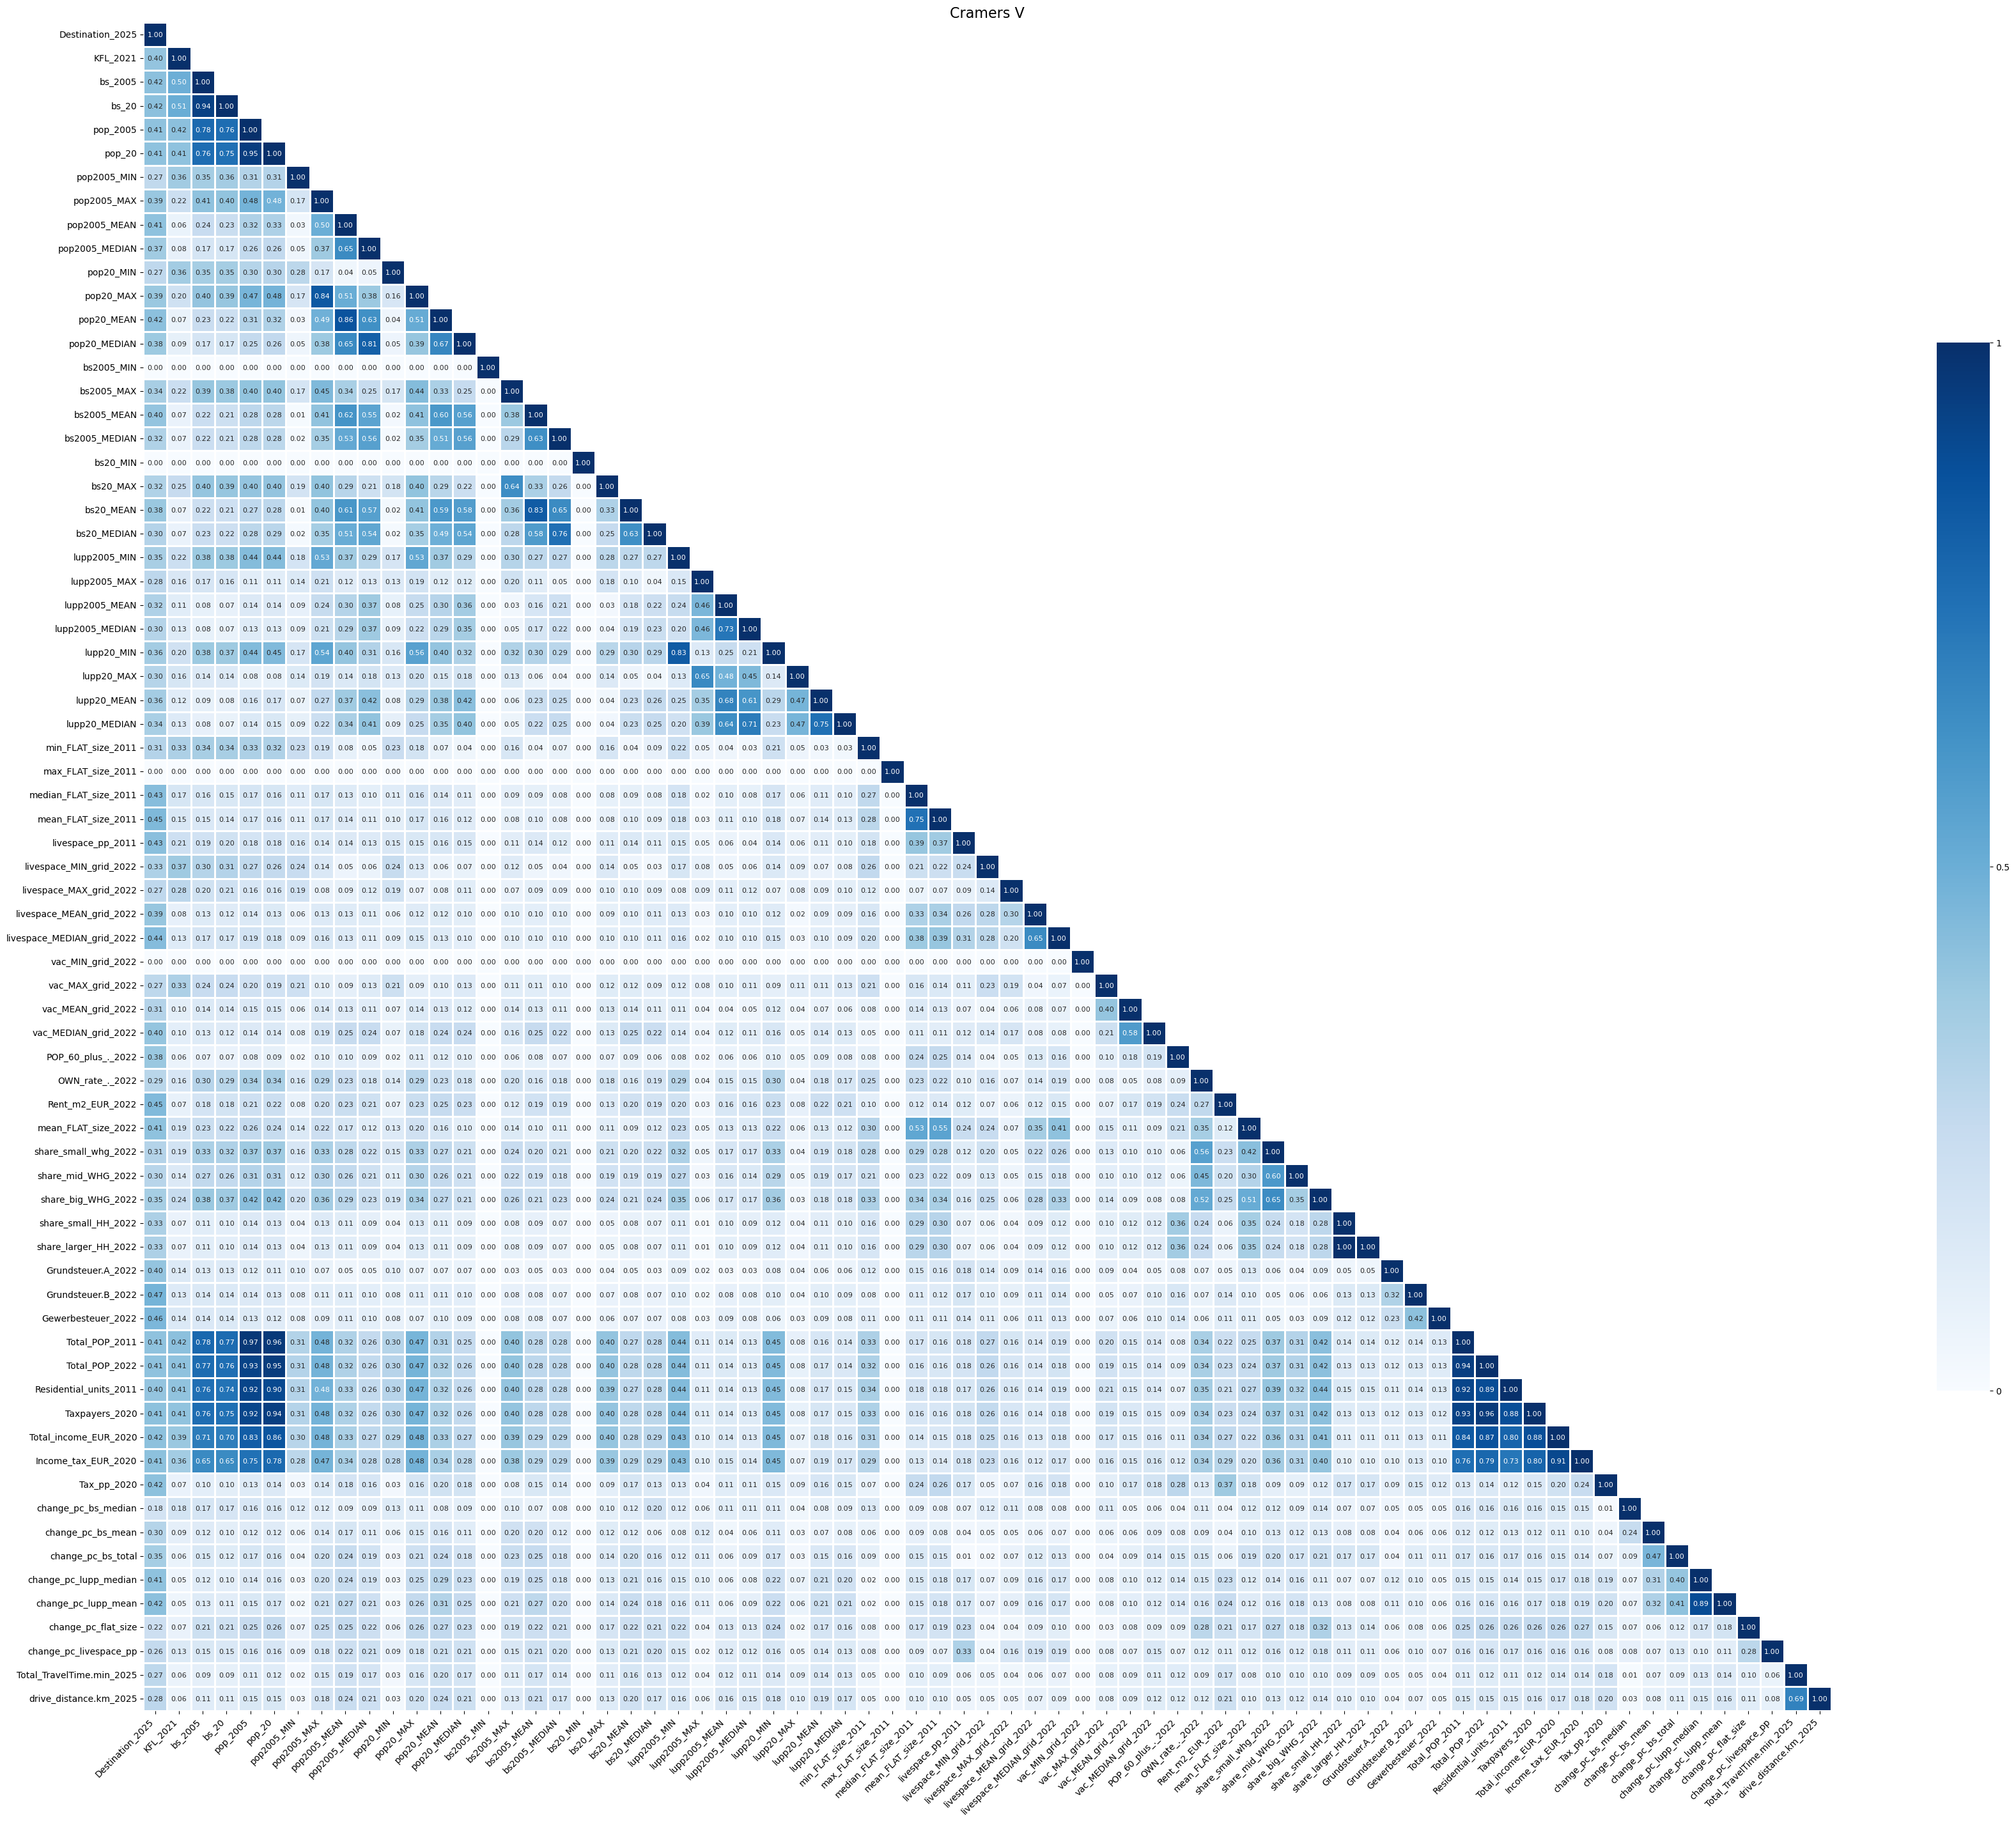

In [11]:
cat_corr_heatmap(matrix)

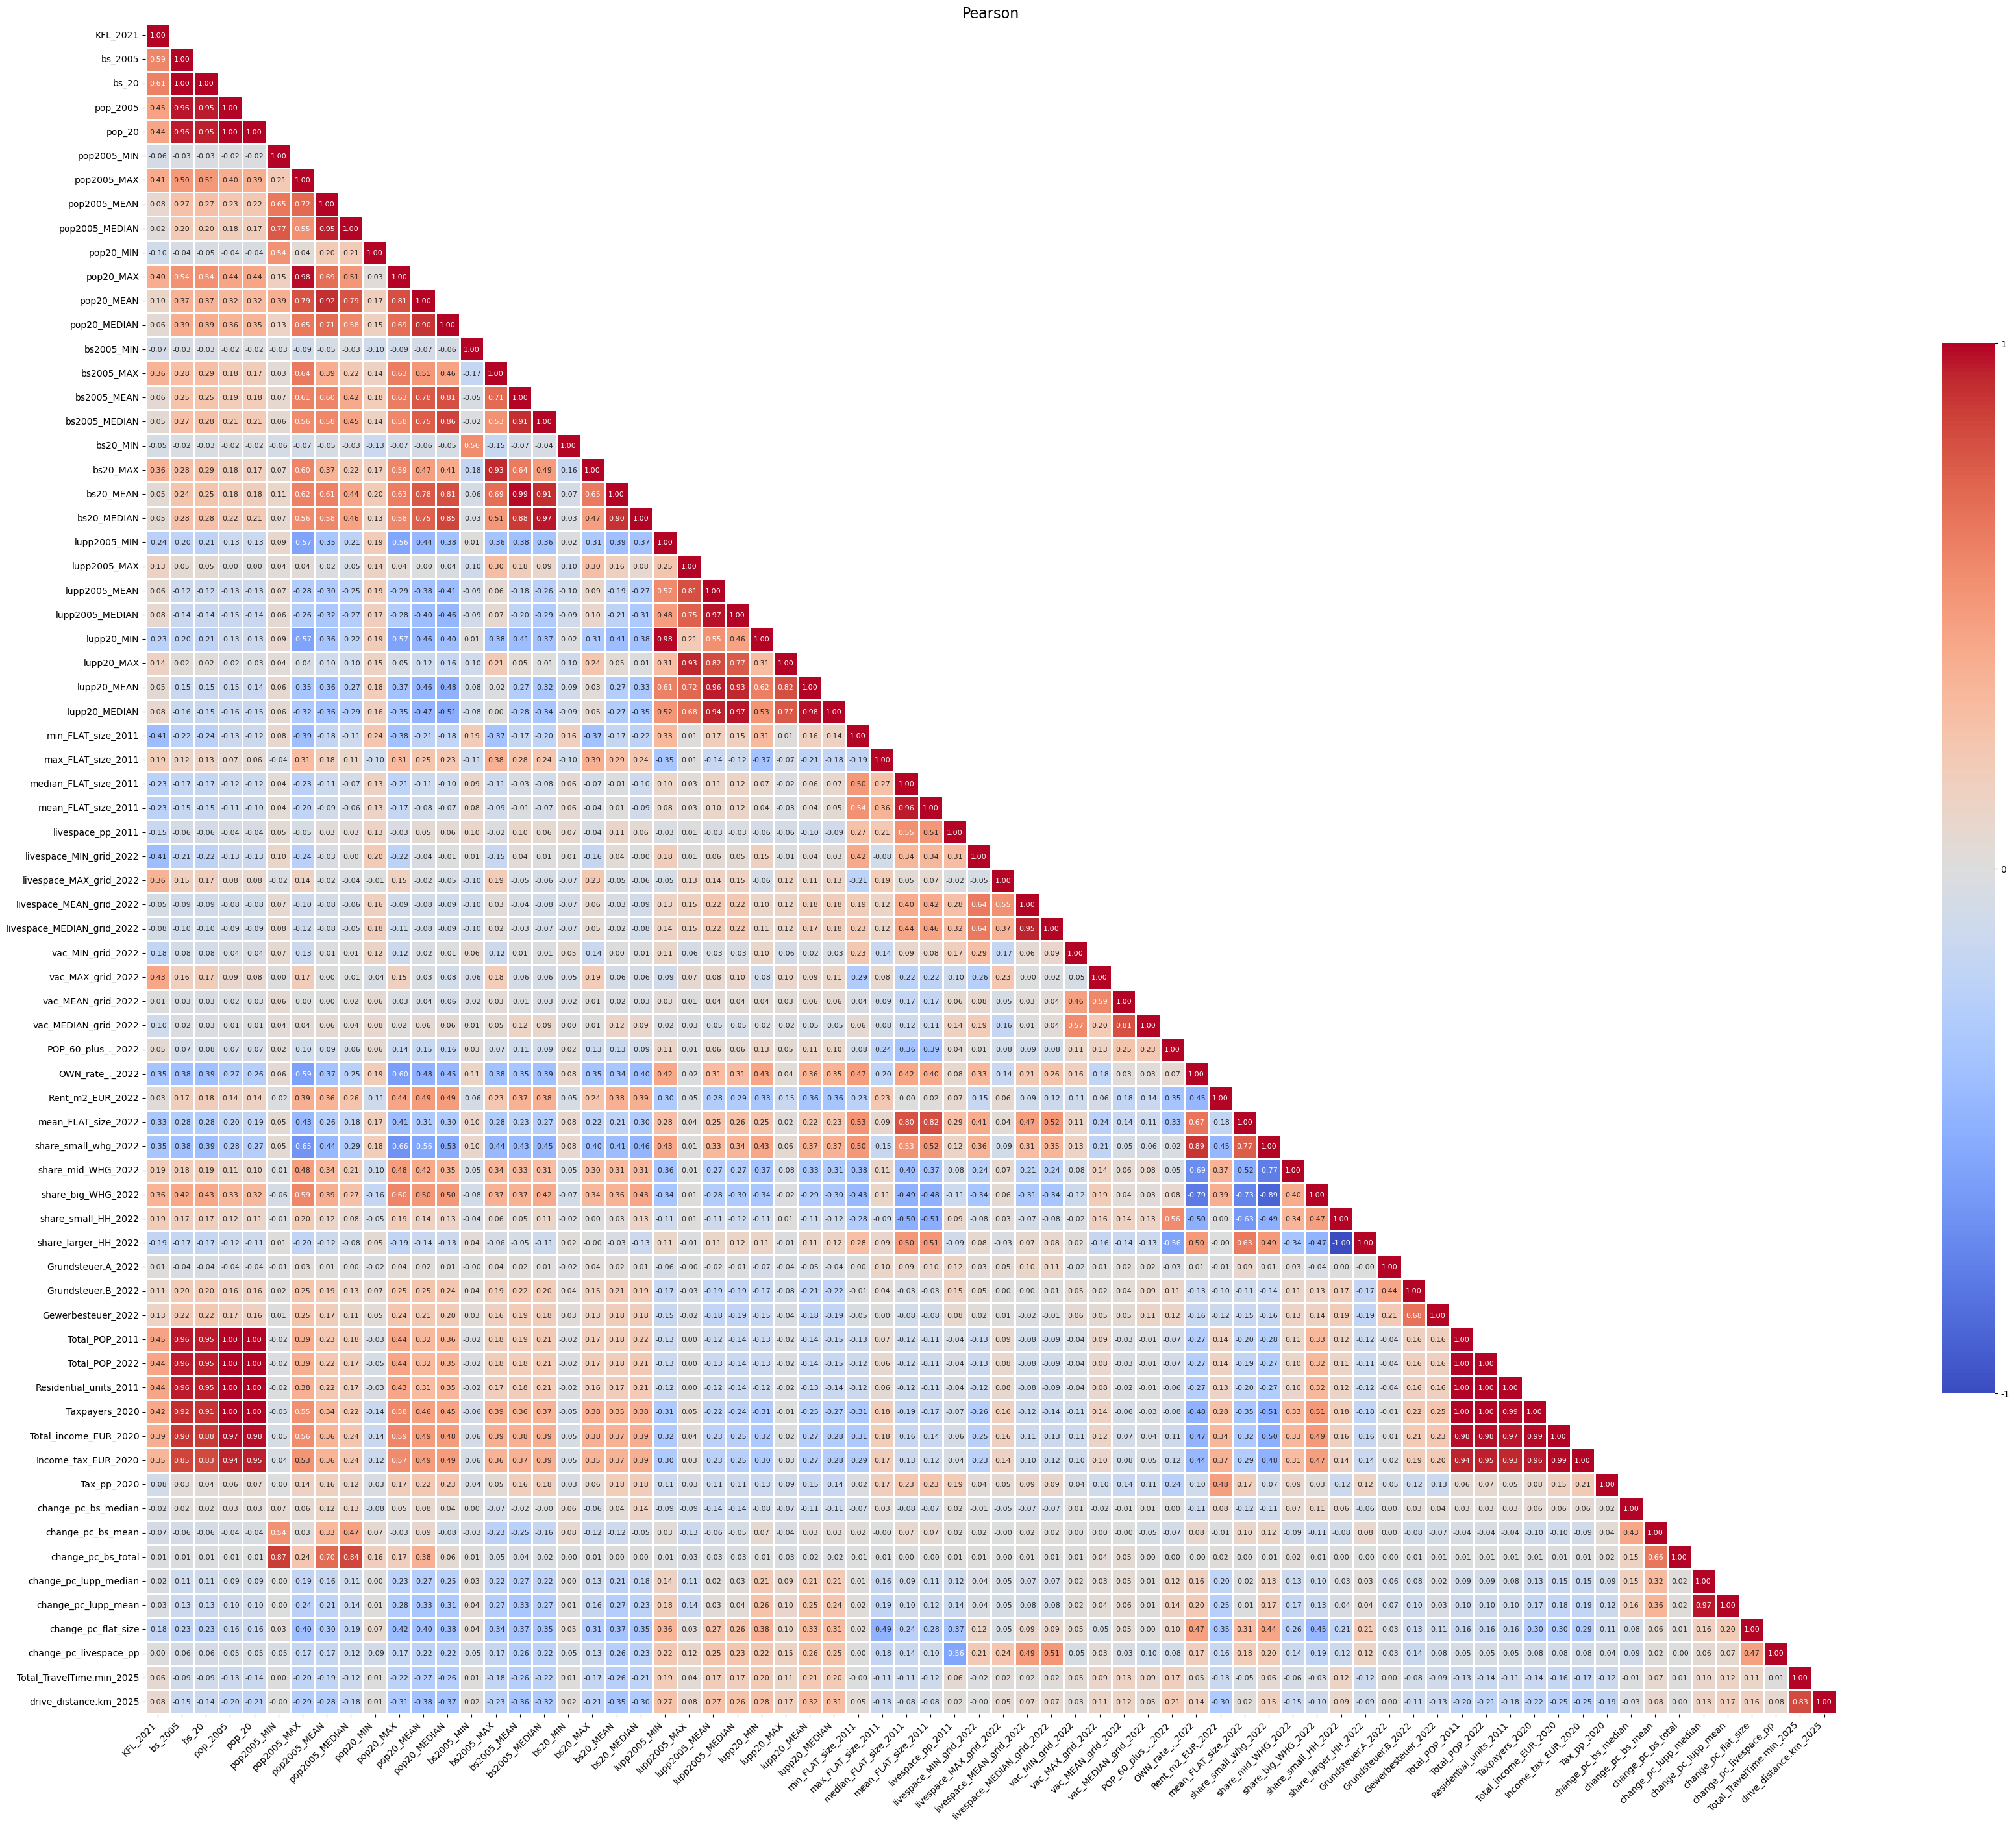

In [12]:
num_corr_heatmap(df.drop(columns=columns_to_drop).corr(numeric_only=True))